In [1]:
import graph
from env.gridworld import Gridworld
import matplotlib.pyplot as plt
import numpy as np
from walks.classical import *

In [2]:
maze_path='env/maze1.txt'
start, goal, obstacles, size = graph.read_layout(maze_path)
print(graph.is_reachable(start, goal, obstacles, size))
print(start, goal, obstacles, size)

states, adj = graph.build_adjacency(size, obstacles)

True
(0, 0) (4, 4) {(3, 1), (0, 2), (1, 2)} 5


In [3]:
env = Gridworld(size=5, render_mode="human", obstacles=obstacles)
obs, info = env.reset(seed=42)

for _ in range(20):
    action = env.action_space.sample(mask=info["action_mask"])
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated:
        print("Reached goal!")
        break


A . # . .
. . # . .
. . . . .
. # . . .
. . . . G

. A # . .
. . # . .
. . . . .
. # . . .
. . . . G

A . # . .
. . # . .
. . . . .
. # . . .
. . . . G

. . # . .
A . # . .
. . . . .
. # . . .
. . . . G

. . # . .
. . # . .
A . . . .
. # . . .
. . . . G

. . # . .
. . # . .
. A . . .
. # . . .
. . . . G

. . # . .
. . # . .
A . . . .
. # . . .
. . . . G

. . # . .
A . # . .
. . . . .
. # . . .
. . . . G

A . # . .
. . # . .
. . . . .
. # . . .
. . . . G

. . # . .
A . # . .
. . . . .
. # . . .
. . . . G

. . # . .
. . # . .
A . . . .
. # . . .
. . . . G

. . # . .
A . # . .
. . . . .
. # . . .
. . . . G

. . # . .
. . # . .
A . . . .
. # . . .
. . . . G

. . # . .
. . # . .
. A . . .
. # . . .
. . . . G

. . # . .
. . # . .
. . A . .
. # . . .
. . . . G

. . # . .
. . # . .
. . . . .
. # A . .
. . . . G

. . # . .
. . # . .
. . A . .
. # . . .
. . . . G

. . # . .
. . # . .
. . . A .
. # . . .
. . . . G

. . # . .
. . # . .
. . A . .
. # . . .
. . . . G

. . # . .
. . # . .
. . . . .
.

In [ ]:
def plot_distribution(pi, states, size, ax=None, title="", vmin=None, vmax=None, cmap="viridis"): 
    grid = np.full((size, size), np.nan)
    for (r, c), i in states.items():
        grid[r, c] = pi[i]
 
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    return im


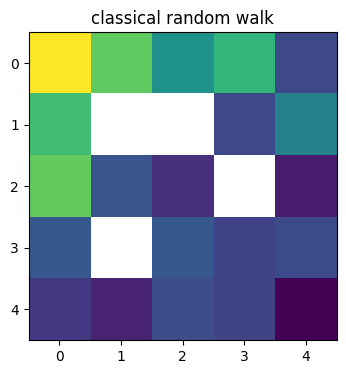

In [6]:
size = 5
obstacles = {(1,1), (1,2), (2,3), (3,1)}

states, A = graph.build_adjacency(size, obstacles)
P = graph.transition_matrix(A)
pi = classical_distribution(P, 50, start=states[(0,0)])

plot_distribution(pi, states, size, title="classical random walk")
plt.show()